# 1. Set up

In [1]:
!pip install pandas
!pip install polars
!pip install scikit-learn
!pip install pyarrow
!pip install torch
!pip install xgboost category_encoders scikit-plot

# 2. Import necessary libraries

In [2]:
import pandas as pd
import polars as pl
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest


import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
import category_encoders as ce
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

# 3. Define global variables

In [3]:
INPUT_EVENTOS_FRAUDE_PATH = "../data/inputs/eventos_fraude_fecha_fin_anomalia_al_31_03_2025.csv"
INPUT_EVENTOS_CONTROL_PATH = "../data/inputs/eventos_control_al_31_03_2025_10000.csv"
INPUT_CONSUMOS_FRAUDE_PATH = "../data/inputs/consumos_fraude_fecha_fin_anomalia_al_31_03_2025.csv"
INPUT_CONSUMOS_CONTROL_PATH = "../data/inputs/consumos_control_al_31_03_2025_10000.csv"
INPUT_CONTADORES_PATH = "../data/inputs/contadores_al_31_05_2025.csv"
INPUT_FRAUDES_PATH = "../data/inputs/fraudes_al_31_03_2025_fecha_fin.csv"
EXPEDIENTES_PATH = "../data/inputs/expedientes.csv"

In [4]:
INPUT_EVENTOS_VALIDACION_FRAUDE_PATH = "../data/inputs/eventos_fraude_al_30_04_2025.csv"
INPUT_EVENTOS_VALIDACION_CONTROL_PATH = "../data/inputs/eventos_control_al_30_04_2025.csv"
INPUT_CONSUMOS_VALIDACION_FRAUDE_PATH = "../data/inputs/consumos_fraude_al_30_04_2025.csv"
INPUT_CONSUMOS_VALIDACION_CONTROL_PATH = "../data/inputs/consumos_control_al_30_04_2025.csv"

In [5]:
train_losses = list()

# 4. Functions

In [6]:
# nn.Module is the baseline of every model in PyTorch
class Autoencoder(nn.Module):
    def __init__(self, input_dim: int):
        # with super() we initialize the object nn.Module
        super().__init__()
        # We define the decoder that goes little by little reducing the dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64), # 64 neurons for the first layer
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64,32), # 32 neurons for the second layer
            nn.ReLU(),
            nn.Linear(32, 16)
            
        )
        # We define the decoder that goes little by little upgrading the dim. Reconstruction part
        self.decoder = nn.Sequential(
            nn.Linear(16, 32), 
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64,input_dim)
        )

    def forward(self, x):
        """
        Forward method that defines how the information flows. It just simply applys the encoder-decoder
        architecture.
        """
        z = self.encoder(x)
        return self.decoder(z)

In [7]:
def crear_pivot_detallado(df: pd.DataFrame, 
                          columnas_inspecciones: list,
                          columnas_eventos: list) -> pd.DataFrame:
    """
    Crea un pivot manteniendo toda la información de conteos por combinación et-c
    """
    # Primero, crear una columna que combine et y c para identificar cada tipo de evento
    df_trabajo = df.copy()
    df_trabajo['tipo_evento'] = df_trabajo['et'].astype(str) + '_' + df_trabajo['c'].astype(str)
   
    # Crear el diccionario de agregación base
    agg_dict = {}
   
    # Para las columnas de inspecciones: tomar el primer valor (son iguales para cada grupo)
    for col in columnas_inspecciones:
        agg_dict[col] = 'first'
   
    # Para las columnas de eventos: necesitamos tratamiento especial
    # Las agregaremos después del groupby usando pivot
   
    # Primero hacer el groupby básico para las columnas de inspecciones
    resultado_base = df_trabajo.groupby(['cups_sgc', 'cnt_id']).agg(agg_dict).reset_index()
   
    # Ahora crear el pivot para las columnas de eventos manteniendo la granularidad
    eventos_pivot_list = []
   
    for col_evento in columnas_eventos:
        # Crear un pivot para cada columna de eventos
        pivot_temp = df_trabajo.pivot_table(
            index=['cups_sgc', 'cnt_id'],
            columns='tipo_evento',
            values=col_evento,
            aggfunc='sum',
            fill_value=0
        ).reset_index()
       
        # Renombrar las columnas para incluir el nombre de la columna original
        pivot_temp.columns = ['cups_sgc', 'cnt_id'] + [f"{col_evento}_{col}" for col in pivot_temp.columns[2:]]
       
        eventos_pivot_list.append(pivot_temp)
   
    # Unir todos los pivots de eventos
    resultado_eventos = eventos_pivot_list[0]
    for pivot in eventos_pivot_list[1:]:
        resultado_eventos = resultado_eventos.merge(
            pivot,
            on=['cups_sgc', 'cnt_id'],
            how='outer'
        )
   
    # Unir con el resultado base (inspecciones)
    resultado_final = resultado_base.merge(
        resultado_eventos,
        on=['cups_sgc', 'cnt_id'],
        how='outer'
    )
   
    return resultado_final

# 5. Code

## 5.1. Parte no supervisada

### 5.1.1. Data processing

In [8]:
def data_processing(INPUT_EVENTOS_CONTROL_PATH: str, 
                    INPUT_EVENTOS_FRAUDE_PATH: str, 
                    INPUT_CONSUMOS_FRAUDE_PATH: str, 
                    INPUT_CONSUMOS_CONTROL_PATH: str):
    # Cargar datos
    eventos_fraude = pl.read_csv(INPUT_EVENTOS_FRAUDE_PATH)
    eventos_control = pl.read_csv(INPUT_EVENTOS_CONTROL_PATH)
    consumos_fraude = pl.read_csv(INPUT_CONSUMOS_FRAUDE_PATH).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
    consumos_control = pl.read_csv(INPUT_CONSUMOS_CONTROL_PATH).drop(["tuvo_fraude_previo", "tuvo_fraude_reciente", "estado_fraude"])
    fraudes = pd.read_csv(INPUT_FRAUDES_PATH).rename(columns={"cups": "cups_sgc", "fraudes_en_90_dias": "target"})

    # Concatenar datos de eventos y consumos
    eventos = pl.concat([eventos_control, eventos_fraude])
    consumos = pl.concat([consumos_control, consumos_fraude])

    # Definir columnas para pivot detallado
    columnas_eventos = [col for col in eventos.columns if col not in ['cups_sgc', 'cnt_id', 'et', 'c'] and "eventos" in col]
    columnas_inspecciones = [col for col in eventos.columns if col not in ['cups_sgc', 'cnt_id', 'et', 'c'] and "inspecciones" in col]

    # Debemos rellenar los nulos de las columnas 'c' y 'et' antes de crear 'tipo_evento'
    eventos = eventos.with_columns([
        pl.col("c").fill_null("NA").cast(pl.Utf8),
        pl.col("et").fill_null("NA").cast(pl.Utf8)
    ])
    
    # Creación de la columna tipo_evento
    eventos = eventos.with_columns(
        (pl.col("et") + "_" + pl.col("c")).alias("tipo_evento")
    )

    # Convertir a pandas para el pivot detallado
    eventos_df_pandas = eventos.to_pandas()
    consumos_pandas = consumos.to_pandas()

    # Ejecutar la función
    print("Creando pivot detallado...")
    eventos_pivotado_detallado = crear_pivot_detallado(eventos_df_pandas, columnas_inspecciones, columnas_eventos)

    print(f"Dimensiones del resultado: {eventos_pivotado_detallado.shape}")
    print(f"Registros originales: {len(eventos)}")

    final_df = eventos_pivotado_detallado.merge(
    consumos_pandas, on=["cups_sgc", "cnt_id"], how="outer").merge(fraudes, on=["cups_sgc"], how="left")

    final_df.drop_duplicates(inplace=True)
    return final_df

print("Data processing for training and test data:")
final_df = data_processing(INPUT_EVENTOS_CONTROL_PATH, INPUT_EVENTOS_FRAUDE_PATH, INPUT_CONSUMOS_FRAUDE_PATH, INPUT_CONSUMOS_CONTROL_PATH)

print(f"Target: {final_df["target"].value_counts()}")

print("Número de filas y columnas:", final_df.shape)
print("\nColumnas:")
print(final_df.columns)

print("\nTipos de columnas:")
print(final_df.dtypes)


Data processing for training and test data:
Creando pivot detallado...
Dimensiones del resultado: (11970, 893)
Registros originales: 159790
Target: target
1.0    2118
Name: count, dtype: int64
Número de filas y columnas: (12118, 1009)

Columnas:
Index(['cups_sgc', 'cnt_id', 'cnt_inspecciones_semana_actual',
       'cnt_inspecciones_semana_pasada',
       'cnt_inspecciones_misma_semana_anio_pasado',
       'cnt_inspecciones_mes_actual', 'cnt_inspecciones_mes_pasado',
       'cnt_inspecciones_mismo_mes_anio_pasado',
       'cnt_inspecciones_trimestre_actual',
       'cnt_inspecciones_trimestre_pasado',
       ...
       'porcentaje_calidad_datos_trimestre_actual_incorrectos',
       'porcentaje_calidad_datos_trimestre_pasado_correctos',
       'porcentaje_calidad_datos_trimestre_pasado_incorrectos',
       'porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos',
       'porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos',
       'porcentaje_calidad_datos_anio_actua

In [9]:

print("Data processing for validation data:")
final_df_validation = data_processing(INPUT_EVENTOS_VALIDACION_CONTROL_PATH, INPUT_EVENTOS_VALIDACION_FRAUDE_PATH, INPUT_CONSUMOS_VALIDACION_FRAUDE_PATH, INPUT_CONSUMOS_VALIDACION_CONTROL_PATH)

print(f"Target: {final_df_validation["target"].value_counts()}")

print("Número de filas y columnas:", final_df_validation.shape)
print("\nColumnas:")
print(final_df_validation.columns)

print("\nTipos de columnas:")
print(final_df_validation.dtypes)

Data processing for validation data:
Creando pivot detallado...
Dimensiones del resultado: (12179, 871)
Registros originales: 174660
Target: target
1.0    1573
Name: count, dtype: int64
Número de filas y columnas: (12300, 987)

Columnas:
Index(['cups_sgc', 'cnt_id', 'cnt_inspecciones_semana_actual',
       'cnt_inspecciones_semana_pasada',
       'cnt_inspecciones_misma_semana_anio_pasado',
       'cnt_inspecciones_mes_actual', 'cnt_inspecciones_mes_pasado',
       'cnt_inspecciones_mismo_mes_anio_pasado',
       'cnt_inspecciones_trimestre_actual',
       'cnt_inspecciones_trimestre_pasado',
       ...
       'porcentaje_calidad_datos_trimestre_actual_incorrectos',
       'porcentaje_calidad_datos_trimestre_pasado_correctos',
       'porcentaje_calidad_datos_trimestre_pasado_incorrectos',
       'porcentaje_calidad_datos_mismo_trimestre_anio_pasado_correctos',
       'porcentaje_calidad_datos_mismo_trimestre_anio_pasado_incorrectos',
       'porcentaje_calidad_datos_anio_actual_correc

In [10]:
# Convertir las columnas a sets para facilitar las operaciones
columnas_final_df = set(final_df.columns)
columnas_validation = set(final_df_validation.columns)

# Columnas que están en final_df pero NO en final_df_validation
columnas_solo_en_final = columnas_final_df - columnas_validation

# Columnas que están en final_df_validation pero NO en final_df
columnas_solo_en_validation = columnas_validation - columnas_final_df

print("Columnas que están en final_df pero NO en final_df_validation:")
print(list(columnas_solo_en_final))
print(f"Total: {len(columnas_solo_en_final)}")

print("\nColumnas que están en final_df_validation pero NO en final_df:")
print(list(columnas_solo_en_validation))
print(f"Total: {len(columnas_solo_en_validation)}")

# Columnas comunes
columnas_comunes = columnas_final_df & columnas_validation
print(f"\nColumnas comunes: {len(columnas_comunes)}")

Columnas que están en final_df pero NO en final_df_validation:
['cnt_eventos_mismo_mes_anio_pasado_1_46', 'cnt_eventos_trimestre_pasado_1_46', 'cnt_eventos_anio_pasado_1_46', 'cnt_eventos_semana_pasada_1_46', 'cnt_eventos_anio_actual_1_46', 'cnt_eventos_trimestre_actual_1_32', 'cnt_eventos_misma_semana_anio_pasado_1_46', 'cnt_eventos_trimestre_pasado_1_32', 'cnt_eventos_semana_pasada_1_32', 'cnt_eventos_semana_actual_1_32', 'cnt_eventos_trimestre_actual_1_46', 'cnt_eventos_anio_actual_1_32', 'cnt_eventos_mes_actual_1_46', 'cnt_eventos_anio_pasado_1_32', 'cnt_eventos_misma_semana_anio_pasado_1_32', 'cnt_eventos_mes_pasado_1_32', 'cnt_eventos_mes_actual_1_32', 'cnt_eventos_mes_pasado_1_46', 'cnt_eventos_mismo_trimestre_anio_pasado_1_46', 'cnt_eventos_semana_actual_1_46', 'cnt_eventos_mismo_mes_anio_pasado_1_32', 'cnt_eventos_mismo_trimestre_anio_pasado_1_32']
Total: 22

Columnas que están en final_df_validation pero NO en final_df:
[]
Total: 0

Columnas comunes: 987


In [11]:
# Añadir estas columnas a final_df_validation con valor 0
for columna in columnas_solo_en_final:
    final_df_validation[columna] = 0

final_df_validation = final_df_validation[list(final_df.columns)]


target_col = "target" 
cat_cols = final_df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = [col for col in cat_cols if col not in ['cups_sgc', 'cnt_id', target_col]]

In [12]:
def create_x_y(final_df: pd.DataFrame, target_col:str):
    X = final_df.drop(columns=[target_col, 'cups_sgc', 'cnt_id'], errors='ignore')
    y = final_df[target_col]
    X = X.apply(pd.to_numeric, errors='coerce')

    # Opción 1: rellenar NaN con 0
    X = X.replace([np.inf, -np.inf], np.nan)
    X = X.fillna(0)

    # Clip very large/small values to avoid dtype errors
    X = X.clip(lower=-1e6, upper=1e6)
    return(X, y)

X, y = create_x_y(final_df, target_col)
scaler = StandardScaler()
# Ahora escalar
X_scaled = scaler.fit_transform(X)

X_validation, y_validation = create_x_y(final_df_validation[list(final_df.columns)], target_col)
# Ahora escalar
scaler_valid = StandardScaler()
X_scaled_validation = scaler_valid.fit_transform(X_validation)

In [13]:
columnas_iguales = X.columns.equals(X_validation.columns)
print(f"¿Las columnas son exactamente iguales?: {columnas_iguales}")

¿Las columnas son exactamente iguales?: True


## 5.3. Modelling

### 5.3.1. DBSCAN cluster

First of all we will use the DBSCAN model. This algorithm is a cluster algorithm based on density. Groups the data that have sufficient neighbors and everything that does not go into a cluster is labeled as -1. Thus, the idea is no more than finiding outliers in the data points.

In [14]:
# Seteamos un radio de 3 alrededor de cada punto y un mínimo de 100 puntos requeridos dentro del vecindario para que un punto sea considerado un punto "core".
db = DBSCAN(eps=3, min_samples=100).fit(X_scaled)
# Identificamos outliers haciendo uso de la etiqueta -1
final_df["anomaly_dbscan"] = db.labels_ == -1

In [15]:
# Seteamos un radio de 3 alrededor de cada punto y un mínimo de 100 puntos requeridos dentro del vecindario para que un punto sea considerado un punto "core".
db_validation = DBSCAN(eps=3, min_samples=100).fit(X_scaled_validation)
# Identificamos outliers haciendo uso de la etiqueta -1
final_df_validation["anomaly_dbscan"] = db_validation.labels_ == -1

Veamos la distribución de las anomalías

In [16]:
final_df["anomaly_dbscan"].value_counts().head(20)

anomaly_dbscan
True    12118
Name: count, dtype: int64

In [17]:
final_df_validation["anomaly_dbscan"].value_counts().head(20)

anomaly_dbscan
True    12300
Name: count, dtype: int64

### 5.3.2. Isolation forest

Isolation forest es un modelo que trata de aislar los puntos de datos. Devuelve un -1 como un outlier y 1 como un punto "normal".

Isolation forest is a model that tries to aisle data points. It returns a -1 as an outlier and a 1 as a normal point. Thus, if we consider that a CUPS has a -1 prediction, it indicates that its metrics are far away from the general distribution.

In [18]:
def isolation_forest(X_scaled, final_df):
    iso = IsolationForest(contamination=0.01, random_state=42)
    preds = iso.fit_predict(X_scaled)
    final_df["anomaly_iso"] = preds == -1
    return(final_df)
final_df = isolation_forest(X_scaled, final_df)
final_df_validation = isolation_forest(X_scaled_validation, final_df_validation)

### 5.3.3. Autoencoders

Now we are going to go with the approach of autoencoders. The idea here is to find big errors when the decoder tries to reconstruct the input. Then we will find anomalies within the magnitude of that error

In [19]:
def autoencoder(X_scaled, final_df):
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    # We create a PyTorch dataset that can be consumed by a DataLoader. TensorDataset is a way of evolving tensors
    # as a simple dataset
    train_data = TensorDataset(X_tensor)
    # We create a data loader that divides the dataset in batches of 256 and shuffles the arrange randomly
    loader = DataLoader(train_data, batch_size=256, shuffle=True)
    model = Autoencoder(input_dim=X_tensor.shape[1])
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model.train()
    for epoch in range(30):
        model.train()
        running_loss = 0
        for batch in loader:
            # we take the batch[0] because TensorDataset only has one input tensor (without target)
            inputs = batch[0]
            outputs = model(inputs)
            loss = criterion(outputs, inputs)
            # we clear the gradients
            optimizer.zero_grad()
            # we calculate the gradients
            loss.backward()
            # we update the weights
            optimizer.step()
            running_loss += loss.item()

    train_losses.append(running_loss / len(loader))

    # Validation
    model.eval()

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f}")
    with torch.no_grad():
        reconstructed_train = model(X_tensor)
    mse_train = torch.mean((X_tensor - reconstructed_train) ** 2, dim=1)
    final_df["reconstruction_error"] = mse_train
    threshold = final_df["reconstruction_error"].quantile(0.99)
    final_df["anomaly_autoencoder"] = final_df["reconstruction_error"] > threshold
    return(final_df)
final_df = autoencoder(X_scaled, final_df)
final_df_validation = autoencoder(X_scaled_validation, final_df_validation)

Epoch 30 | Train Loss: 0.5353
Epoch 30 | Train Loss: 0.5729


In [20]:
# X_tensor = torch.tensor(X_scaled, dtype=torch.float32)

# # We create a PyTorch dataset that can be consumed by a DataLoader. TensorDataset is a way of evolving tensors
# # as a simple dataset
# train_data = TensorDataset(X_tensor)
# # We create a data loader that divides the dataset in batches of 256 and shuffles the arrange randomly
# loader = DataLoader(train_data, batch_size=256, shuffle=True)

In [21]:
# model = Autoencoder(input_dim=X_tensor.shape[1])
# criterion = nn.MSELoss()
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [22]:
# model.train()

In [23]:
# for epoch in range(30):
#     model.train()
#     running_loss = 0
#     for batch in loader:
#         # we take the batch[0] because TensorDataset only has one input tensor (without target)
#         inputs = batch[0]
#         outputs = model(inputs)
#         loss = criterion(outputs, inputs)
#         # we clear the gradients
#         optimizer.zero_grad()
#         # we calculate the gradients
#         loss.backward()
#         # we update the weights
#         optimizer.step()
#         running_loss += loss.item()

#     train_losses.append(running_loss / len(loader))

#     # Validation
#     model.eval()

#     print(f"Epoch {epoch+1:02d} | Train Loss: {train_losses[-1]:.4f}")

We deactivate the gradient calculations (we save memory) and pass all the inputs to the model in order to get the reconstruction



In [24]:
# with torch.no_grad():
#     reconstructed_train = model(X_tensor)

In [25]:
# mse_train = torch.mean((X_tensor - reconstructed_train) ** 2, dim=1)
# final_df["reconstruction_error"] = mse_train
# threshold = final_df["reconstruction_error"].quantile(0.99)
# final_df["anomaly_autoencoder"] = final_df["reconstruction_error"] > threshold

### 5.1.4. Resultados no supervisados

The idea here is to combine both anomalies, the one from DBSCAN and the one from the isolation forest. Those cups with most anomalies will be the strangest ones. Thus, we sum the anomalies columns and we set them as a possible fraud score.

In [26]:
def resultados(final_df):
    final_df["fraude_score_no_supervisado"] = final_df["anomaly_dbscan"].astype(int) + final_df["anomaly_iso"].astype(int) + final_df["reconstruction_error"]
    scaler = MinMaxScaler()
    final_df["fraude_score_no_supervisado_norm"] = scaler.fit_transform(final_df[["fraude_score_no_supervisado"]])
    return(final_df)
final_df = resultados(final_df)
final_df_validation = resultados(final_df_validation)

In [27]:
# final_df["fraude_score_no_supervisado"] = final_df["anomaly_dbscan"].astype(int) + final_df["anomaly_iso"].astype(int) + final_df["reconstruction_error"]

In [28]:
columnas_iguales = final_df.columns.equals(final_df_validation.columns)
print(f"¿Las columnas son exactamente iguales?: {columnas_iguales}")

¿Las columnas son exactamente iguales?: True


In [29]:
len(final_df.columns)

1015

In [30]:
len(final_df_validation.columns)

1015

In [31]:
# Encontrar diferencias
cols_final_df = set(final_df.columns)
cols_final_df_validation = set(final_df_validation.columns)

solo_en_final_df = cols_final_df - cols_final_df_validation
solo_en_final_df_validation = cols_final_df_validation - cols_final_df
comunes = cols_final_df & cols_final_df_validation


In [32]:
print(f"\nColumnas comunes: {len(comunes)}")
print(f"Solo en final_df: {len(solo_en_final_df)}")
print(f"Solo en final_df_validation: {len(solo_en_final_df_validation)}")

if solo_en_final_df:
    print(f"\nColumnas solo en X: {list(solo_en_final_df)}")
    
if solo_en_final_df_validation:
    print(f"\nColumnas solo en X_validation: {list(solo_en_final_df_validation)}")


Columnas comunes: 1015
Solo en final_df: 0
Solo en final_df_validation: 0


In [33]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# final_df["fraude_score_no_supervisado_norm"] = scaler.fit_transform(
#     final_df[["fraude_score_no_supervisado"]]
# )

In [34]:
top20 = final_df.sort_values("fraude_score_no_supervisado_norm", ascending=False).head(20)

top20

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target,anomaly_dbscan,anomaly_iso,reconstruction_error,anomaly_autoencoder,fraude_score_no_supervisado,fraude_score_no_supervisado_norm
6547,ES0022000007695500JD1P,ITE0131414552,0.0,0.0,27.0,0.0,0.0,27.0,0.0,0.0,...,0.00,95.36,0.00,NaN,True,False,98.470642,True,99.470642,1.000000
7846,ES0022000008200152NH1P,SOG0100066471,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.94,47.56,3.13,NaN,True,True,92.647148,True,94.647148,0.951012
10191,ES0022000008702004MX1P,SOG0100050773,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,52.17,0.00,NaN,True,False,87.760536,True,88.760536,0.891227
8318,ES0022000008330314ZT1P,SOG0100059080,0.0,0.0,0.0,0.0,0.0,0.0,0.0,58.0,...,4.21,98.09,0.00,NaN,True,False,85.579132,True,86.579132,0.869073
2885,ES0022000005544040NS1P,LGZ0018745560,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,96.98,0.00,NaN,True,False,53.727562,True,54.727562,0.545586
10769,ES0022000008796191YN1P,ZIV0048614517,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,72.94,0.00,NaN,True,False,52.194012,True,53.194012,0.530012
2595,ES0022000005536202QC1P,SAG0156138365,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,67.66,0.17,NaN,True,True,50.754070,True,52.754070,0.525544
2324,ES0022000005529111FJ1P,SAG0146440042,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.91,28.89,21.45,NaN,True,True,50.749088,True,52.749088,0.525493
3003,ES0022000005547304QJ1P,SAG0146455961,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,75.46,0.93,68.43,NaN,True,True,45.336288,True,47.336288,0.470520
11310,ES0022000008904547WS1P,SAG0231813415,0.0,0.0,28.0,0.0,0.0,28.0,0.0,0.0,...,0.00,62.00,0.00,NaN,True,False,40.994026,True,41.994026,0.416264


In [35]:
top20_validation = final_df_validation.sort_values("fraude_score_no_supervisado_norm", ascending=False).head(20)

top20_validation

,cups_sgc,cnt_id,cnt_inspecciones_semana_actual,cnt_inspecciones_semana_pasada,cnt_inspecciones_misma_semana_anio_pasado,cnt_inspecciones_mes_actual,cnt_inspecciones_mes_pasado,cnt_inspecciones_mismo_mes_anio_pasado,cnt_inspecciones_trimestre_actual,cnt_inspecciones_trimestre_pasado,...,porcentaje_calidad_datos_anio_actual_incorrectos,porcentaje_calidad_datos_anio_anterior_correctos,porcentaje_calidad_datos_anio_anterior_incorrectos,target,anomaly_dbscan,anomaly_iso,reconstruction_error,anomaly_autoencoder,fraude_score_no_supervisado,fraude_score_no_supervisado_norm
10412,ES0022000008702004MX1P,SOG0100050773,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,52.17,0.00,NaN,True,False,87.901169,True,88.901169,1.000000
793,ES0022000004957769YZ1P,ZIV0040109372,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.52,53.77,21.90,1.0,True,True,83.830490,True,85.830490,0.965064
7014,ES0022000007840266MJ1P,SOG0940086619,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.90,95.88,0.02,NaN,True,False,79.936981,True,80.936981,0.909389
3645,ES0022000005563676SD1P,SOG0100065017,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,0.02,0.00,NaN,True,False,79.772125,True,80.772125,0.907513
6084,ES0022000007517771ZR1P,LGZ0018738958,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.39,93.06,3.65,NaN,True,False,77.039299,True,78.039299,0.876421
2401,ES0022000005529653PA1P,ITE0131414618,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.00,94.77,0.00,NaN,True,False,74.561913,True,75.561913,0.848235
2923,ES0022000005544227CH1P,LGZ0018738859,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.07,43.29,0.02,NaN,True,False,69.124275,True,70.124275,0.786370
3166,ES0022000005551221WC1P,SOG0040015107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.03,99.25,0.07,NaN,True,False,64.983932,True,65.983932,0.739264
9008,ES0022000008455327KP1P,SAG0155274607,0.0,0.0,0.0,0.0,0.0,56.0,0.0,0.0,...,0.07,92.85,0.02,NaN,True,False,61.492016,True,62.492016,0.699535
10660,ES0022000008743128EX1P,ZIV0045738968,28.0,28.0,0.0,28.0,28.0,0.0,28.0,28.0,...,0.21,92.36,0.06,NaN,True,True,56.838772,True,58.838772,0.657971


## 5.4. Modelo baseline supervisado

In [36]:
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

In [37]:
X_validation.fillna(0, inplace=True)
y_validation.fillna(0, inplace=True)

In [38]:
columnas_iguales = X.columns.equals(X_validation.columns)
print(f"¿Las columnas son exactamente iguales?: {columnas_iguales}")

¿Las columnas son exactamente iguales?: True


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

encoder = ce.TargetEncoder(cols=cat_cols)
X_train_enc = encoder.fit_transform(X_train, y_train)
X_test_enc = encoder.transform(X_test)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='auc',
    random_state=42
)
model.fit(X_train_enc, y_train)


c:\Users\GAZARAGOZAG-local\Documents\UFD\Repo_2\ufd-dataia-deteccion-fraude\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:24:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


In [39]:
y_train.value_counts()

target
0.0    8000
1.0    1694
Name: count, dtype: int64

In [40]:
y_test.value_counts()

target
0.0    2000
1.0     424
Name: count, dtype: int64

In [41]:
ufd_orange = "#f26122"
ufd_blue = "#003865"
ufd_gray = "#cccccc"

### Medidas en test

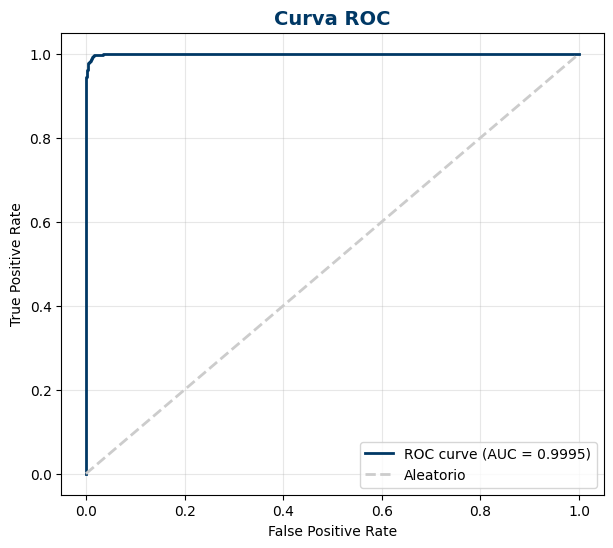

ROC AUC Score: 0.9995


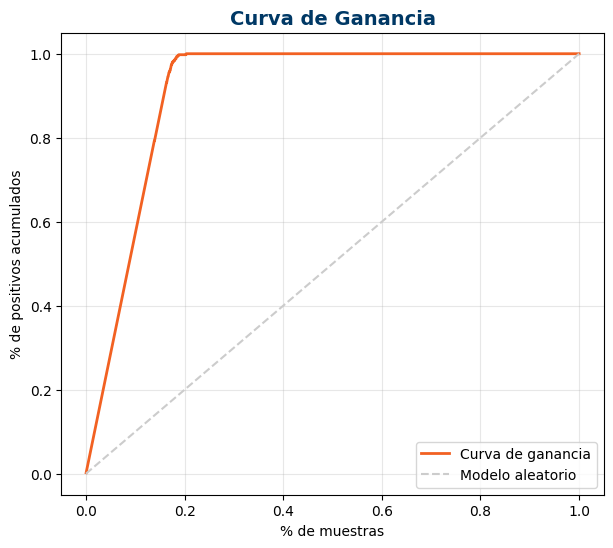

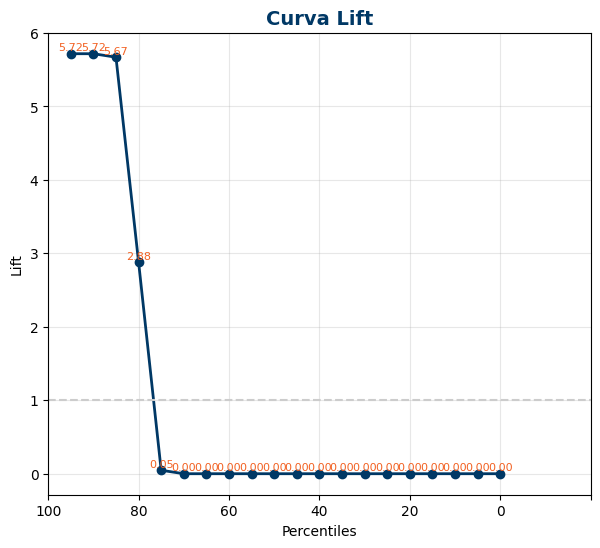

In [42]:
# =====================
# Predicciones
# =====================
y_proba = model.predict_proba(X_test_enc)[:, 1] 
y_proba_train = model.predict_proba(X_train_enc)[:, 1] 
y_pred = model.predict(X_test_enc)

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")


# =====================
# Curva de Ganancia
# =====================
def plot_gain(y_true, y_proba):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    cum_gains = np.cumsum(y_sorted) / sum(y_sorted)
    perc_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

    plt.figure(figsize=(7,6))
    plt.plot(perc_samples, cum_gains, color=ufd_orange, lw=2, label="Curva de ganancia")
    plt.plot([0,1], [0,1], linestyle="--", color=ufd_gray, label="Modelo aleatorio")

    # Estilo
    plt.grid(alpha=0.3)
    plt.xlabel("% de muestras")
    plt.ylabel("% de positivos acumulados")
    plt.title("Curva de Ganancia", fontsize=14, weight="bold", color=ufd_blue)
    plt.legend()
    plt.show()

plot_gain(y_test, y_proba)


# =====================
# Curva Lift
# =====================
def plot_lift(y_true, y_proba, bins=10):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    total_positives_rate = sum(y_sorted) / len(y_sorted)
    group_size = len(y_sorted) // bins
    lift = []

    for i in range(bins):
        start = i * group_size
        end = (i+1) * group_size if i < bins-1 else len(y_sorted)
        group = y_sorted[start:end]
        group_rate = sum(group) / len(group)
        lift.append(group_rate / total_positives_rate)

    # Percentiles crecientes (para graficar normalmente)
    percentiles = list(range(0, 101, int(100/bins)))[1:]  

    plt.figure(figsize=(7,6))
    plt.plot(percentiles, lift, marker="o", color=ufd_blue, lw=2)

    # Etiquetas con valores en cada punto
    for x, val in zip(percentiles, lift):
        plt.text(x, val+0.04, f"{val:.2f}", ha="center", fontsize=8, color=ufd_orange)

    plt.axhline(1, color=ufd_gray, linestyle="--")
    plt.grid(alpha=0.3)
    plt.xlabel("Percentiles")
    plt.ylabel("Lift")
    plt.title("Curva Lift", fontsize=14, weight="bold", color=ufd_blue)

    # Cambiar etiquetas del eje X: 100 → 0
    ticks = plt.xticks()[0]
    new_labels = [str(100 - int(t)) if t >= 0 and t <= 100 else "" for t in ticks]
    plt.xticks(ticks, new_labels)

    plt.show()

# Ejemplo
plot_lift(y_test, y_proba, bins=20)

In [43]:
# First, get the indices of the test set in final_df
test_indices = X_test.index
train_indices = X_train.index

# Assign the predicted probabilities to the correct rows
final_df.loc[test_indices, "xgb_pred_proba"] = y_proba
final_df.loc[train_indices, "xgb_pred_proba"] = y_proba_train

In [44]:
final_df["final_scoring"] = final_df["fraude_score_no_supervisado_norm"]*0.3 + final_df["xgb_pred_proba"]*0.7

In [45]:
from sklearn.metrics import confusion_matrix, classification_report
# Crear la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1991    9]
 [   9  415]]


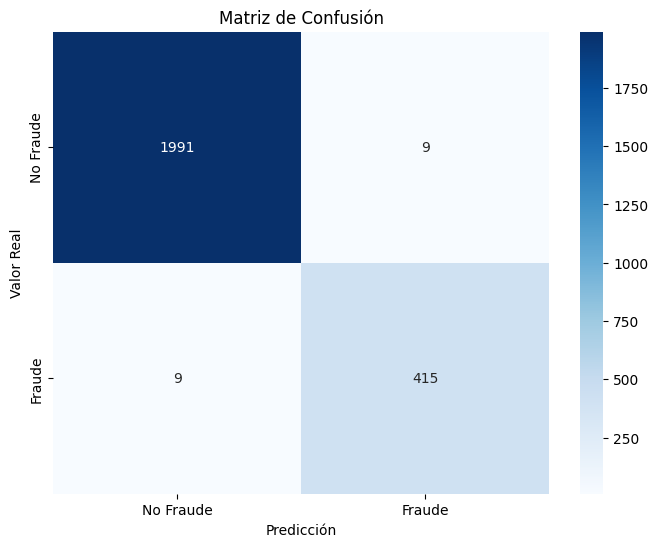


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      2000
         1.0       0.98      0.98      0.98       424

    accuracy                           0.99      2424
   macro avg       0.99      0.99      0.99      2424
weighted avg       0.99      0.99      0.99      2424



In [46]:
# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fraude', 'Fraude'], 
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Identificar falsos positivos

In [47]:
# Identificar los falsos positivos
# Casos donde y_test == 0 (no fraude) pero y_pred == 1 (predicho como fraude)
falsos_positivos_mask = (y_test == 0) & (y_pred == 1)

# Obtener los índices de estos registros
indices_falsos_positivos = y_test[falsos_positivos_mask].index

# Obtener las probabilidades de estos registros
probabilidades_falsos_positivos = y_proba[falsos_positivos_mask]

# Crear un DataFrame con la información de los falsos positivos
falsos_positivos_df = pd.DataFrame({
    'indice': indices_falsos_positivos,
    'y_test_real': y_test[falsos_positivos_mask],
    'y_pred': y_pred[falsos_positivos_mask],
    'probabilidad_fraude': probabilidades_falsos_positivos
}).reset_index(drop=True)

print(f"Número de falsos positivos: {len(falsos_positivos_df)}")
print("\nFalsos positivos (ordenados por probabilidad descendente):")
falsos_positivos_df_ordenado = falsos_positivos_df.sort_values('probabilidad_fraude', ascending=False)
print(falsos_positivos_df_ordenado)

Número de falsos positivos: 9

Falsos positivos (ordenados por probabilidad descendente):
   indice  y_test_real  y_pred  probabilidad_fraude
4    4817          0.0       1             0.988442
1    2499          0.0       1             0.939872
7    7753          0.0       1             0.907425
8    8726          0.0       1             0.875084
5    7302          0.0       1             0.865270
3    3994          0.0       1             0.857237
0    1593          0.0       1             0.849225
6    5909          0.0       1             0.723596
2    6903          0.0       1             0.644877


In [48]:
# Obtener información completa de estos registros desde final_df
# Usando los índices del conjunto de test
info_completa_falsos_positivos = final_df.loc[indices_falsos_positivos, 
                                              ['cups_sgc', 'cnt_id', 'target', 'xgb_pred_proba']].copy()

# Agregar la información de predicción
info_completa_falsos_positivos['y_pred'] = y_pred[falsos_positivos_mask]
info_completa_falsos_positivos['probabilidad_fraude'] = probabilidades_falsos_positivos

# Ordenar por probabilidad descendente
info_completa_falsos_positivos = info_completa_falsos_positivos.sort_values('probabilidad_fraude', ascending=False)

print("Información completa de los falsos positivos:")
print(info_completa_falsos_positivos)

Información completa de los falsos positivos:
                    cups_sgc         cnt_id  target  xgb_pred_proba  y_pred  \
4817  ES0022000007041120JW1P  SAG0165501472     0.0        0.988442       1   
2499  ES0022000005533857YK1P  SAG0156149509     0.0        0.939872       1   
7753  ES0022000008163150ZT1P  SAG0115244300     0.0        0.907425       1   
8726  ES0022000008438164BA1P  SOG0040068686     0.0        0.875084       1   
7302  ES0022000007988644QH1P  SOG0100032138     0.0        0.865270       1   
3994  ES0022000005574216JS1P  ZIV0048396416     0.0        0.857237       1   
1593  ES0022000005510589FY1P  SAG0135219772     0.0        0.849225       1   
5909  ES0022000007455005EW1P  SAG0126302643     0.0        0.723596       1   
6903  ES0022000007835182ZN1P  SOG0100030471     0.0        0.644877       1   

      probabilidad_fraude  
4817             0.988442  
2499             0.939872  
7753             0.907425  
8726             0.875084  
7302             0.8652

In [49]:
#info_completa_falsos_positivos.to_csv("falsos_positivos.csv", index=False)

### Medidas en validation

In [50]:

X_validation_enc = encoder.transform(X_validation)

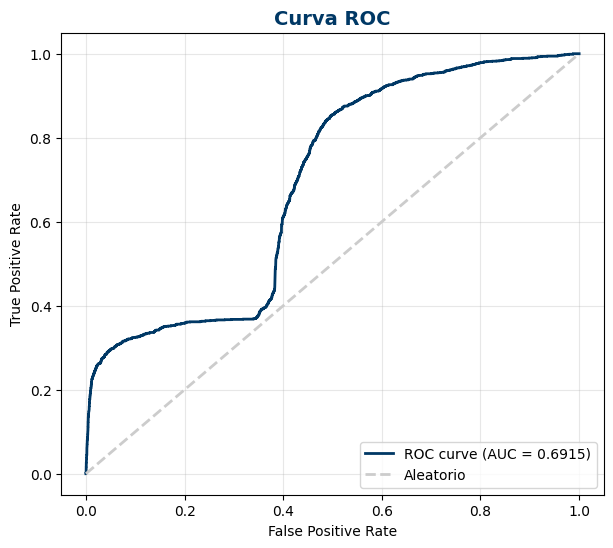

ROC AUC Score: 0.6915


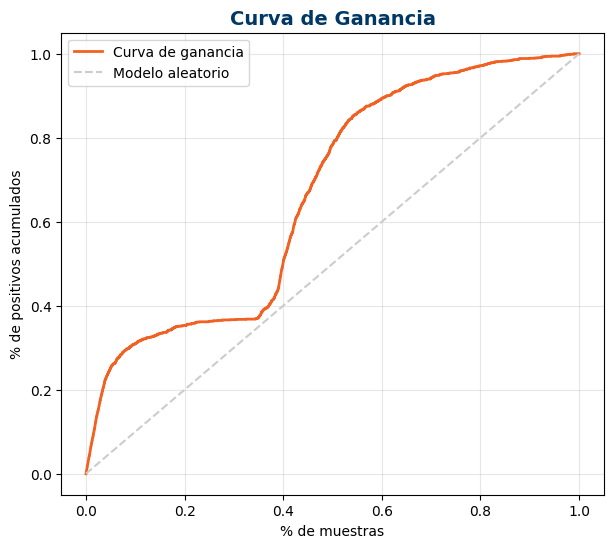

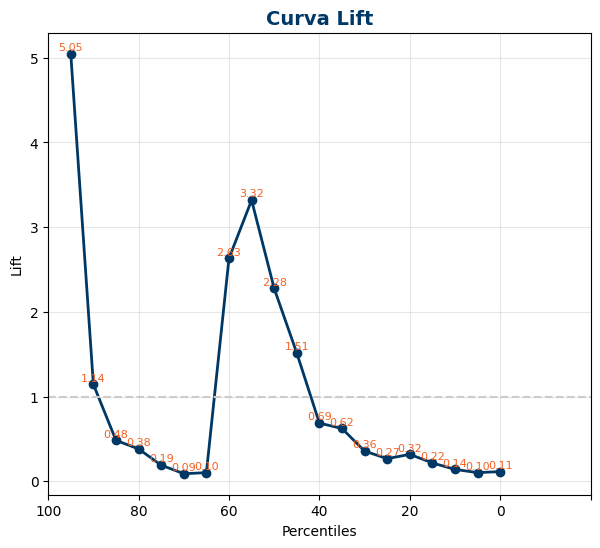

In [51]:
# =====================
# Predicciones
# =====================
y_proba_validation = model.predict_proba(X_validation_enc)[:, 1] 
y_pred_validation = model.predict(X_validation_enc)

fpr, tpr, thresholds = roc_curve(y_validation, y_proba_validation)
roc_auc = roc_auc_score(y_validation, y_proba_validation)

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color=ufd_blue, lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color=ufd_gray, lw=2, linestyle="--", label="Aleatorio")

# Estilo
plt.grid(alpha=0.3)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC", fontsize=14, weight="bold", color=ufd_blue)
plt.legend(loc="lower right", fontsize=10)
plt.show()

print(f"ROC AUC Score: {roc_auc:.4f}")


# =====================
# Curva de Ganancia
# =====================
def plot_gain(y_true, y_proba):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    cum_gains = np.cumsum(y_sorted) / sum(y_sorted)
    perc_samples = np.arange(1, len(y_sorted)+1) / len(y_sorted)

    plt.figure(figsize=(7,6))
    plt.plot(perc_samples, cum_gains, color=ufd_orange, lw=2, label="Curva de ganancia")
    plt.plot([0,1], [0,1], linestyle="--", color=ufd_gray, label="Modelo aleatorio")

    # Estilo
    plt.grid(alpha=0.3)
    plt.xlabel("% de muestras")
    plt.ylabel("% de positivos acumulados")
    plt.title("Curva de Ganancia", fontsize=14, weight="bold", color=ufd_blue)
    plt.legend()
    plt.show()

plot_gain(y_validation, y_proba_validation)


# =====================
# Curva Lift
# =====================
def plot_lift(y_true, y_proba, bins=10):
    data = list(zip(y_true, y_proba))
    data = sorted(data, key=lambda x: x[1], reverse=True)
    y_sorted = np.array([d[0] for d in data])

    total_positives_rate = sum(y_sorted) / len(y_sorted)
    group_size = len(y_sorted) // bins
    lift = []

    for i in range(bins):
        start = i * group_size
        end = (i+1) * group_size if i < bins-1 else len(y_sorted)
        group = y_sorted[start:end]
        group_rate = sum(group) / len(group)
        lift.append(group_rate / total_positives_rate)

    # Percentiles crecientes (para graficar normalmente)
    percentiles = list(range(0, 101, int(100/bins)))[1:]  

    plt.figure(figsize=(7,6))
    plt.plot(percentiles, lift, marker="o", color=ufd_blue, lw=2)

    # Etiquetas con valores en cada punto
    for x, val in zip(percentiles, lift):
        plt.text(x, val+0.04, f"{val:.2f}", ha="center", fontsize=8, color=ufd_orange)

    plt.axhline(1, color=ufd_gray, linestyle="--")
    plt.grid(alpha=0.3)
    plt.xlabel("Percentiles")
    plt.ylabel("Lift")
    plt.title("Curva Lift", fontsize=14, weight="bold", color=ufd_blue)

    # Cambiar etiquetas del eje X: 100 → 0
    ticks = plt.xticks()[0]
    new_labels = [str(100 - int(t)) if t >= 0 and t <= 100 else "" for t in ticks]
    plt.xticks(ticks, new_labels)

    plt.show()

# Ejemplo
plot_lift(y_validation, y_proba_validation, bins=20)

In [52]:
# First, get the indices of the test set in final_df
validation_indices = X_validation.index

# Assign the predicted probabilities to the correct rows
final_df_validation.loc[validation_indices, "xgb_pred_proba"] = y_proba_validation

In [53]:
final_df_validation["final_scoring"] = final_df_validation["fraude_score_no_supervisado_norm"]*0.3 + final_df_validation["xgb_pred_proba"]*0.7

In [54]:
cm = confusion_matrix(y_validation, y_pred_validation)
print(cm)

[[9974  753]
 [1085  488]]


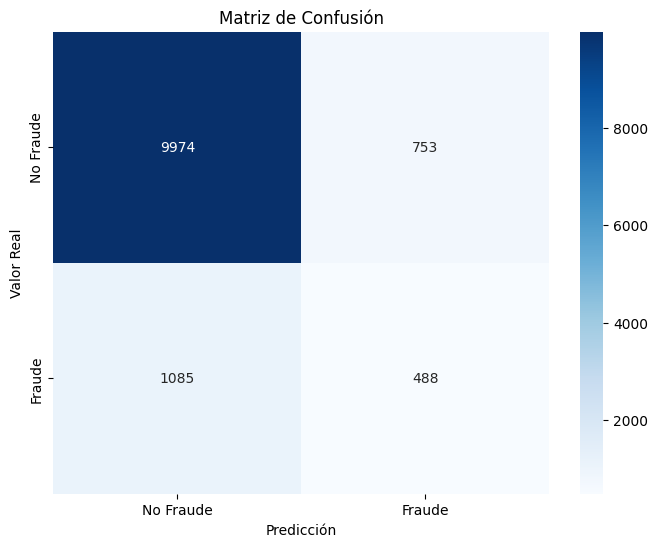


Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.90      0.93      0.92     10727
         1.0       0.39      0.31      0.35      1573

    accuracy                           0.85     12300
   macro avg       0.65      0.62      0.63     12300
weighted avg       0.84      0.85      0.84     12300



In [55]:
# Crear una visualización más clara
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fraude', 'Fraude'], 
            yticklabels=['No Fraude', 'Fraude'])
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

# También puedes mostrar el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y_validation, y_pred_validation))

In [56]:
# Identificar los falsos positivos
# Casos donde y_test == 0 (no fraude) pero y_pred == 1 (predicho como fraude)
falsos_positivos_mask_validation = (y_validation == 0) & (y_pred_validation == 1)

# Obtener los índices de estos registros
indices_falsos_positivos_validation = y_validation[falsos_positivos_mask_validation].index

# Obtener las probabilidades de estos registros
probabilidades_falsos_positivos_validation = y_proba_validation[falsos_positivos_mask_validation]

# Crear un DataFrame con la información de los falsos positivos
falsos_positivos_df_validation = pd.DataFrame({
    'indice': indices_falsos_positivos_validation,
    'y_test_real': y_validation[falsos_positivos_mask_validation],
    'y_pred': y_pred_validation[falsos_positivos_mask_validation],
    'probabilidad_fraude': probabilidades_falsos_positivos_validation
}).reset_index(drop=True)

print(f"Número de falsos positivos: {len(falsos_positivos_df_validation)}")
print("\nFalsos positivos (ordenados por probabilidad descendente):")
falsos_positivos_df_validation_ordenado = falsos_positivos_df_validation.sort_values('probabilidad_fraude', ascending=False)
print(falsos_positivos_df_validation_ordenado)

Número de falsos positivos: 753

Falsos positivos (ordenados por probabilidad descendente):
     indice  y_test_real  y_pred  probabilidad_fraude
398    6457          0.0       1             0.999774
40      819          0.0       1             0.999742
394    6418          0.0       1             0.999699
257    4460          0.0       1             0.999678
24      580          0.0       1             0.999553
..      ...          ...     ...                  ...
108    1963          0.0       1             0.501610
420    6779          0.0       1             0.501391
502    8169          0.0       1             0.500807
602    9605          0.0       1             0.500690
697   11426          0.0       1             0.500078

[753 rows x 4 columns]


In [57]:
# Obtener información completa de estos registros desde final_df
# Usando los índices del conjunto de test
info_completa_falsos_positivos_validation = final_df_validation.loc[indices_falsos_positivos_validation, 
                                              ['cups_sgc', 'cnt_id', 'target', 'xgb_pred_proba']].copy()

# Agregar la información de predicción
info_completa_falsos_positivos_validation['y_pred'] = y_pred_validation[falsos_positivos_mask_validation]
info_completa_falsos_positivos_validation['probabilidad_fraude'] = probabilidades_falsos_positivos_validation

# Ordenar por probabilidad descendente
info_completa_falsos_positivos_validation = info_completa_falsos_positivos_validation.sort_values('probabilidad_fraude', ascending=False)

print("Información completa de los falsos positivos:")
print(info_completa_falsos_positivos_validation)

Información completa de los falsos positivos:
                     cups_sgc         cnt_id  target  xgb_pred_proba  y_pred  \
6457   ES0022000007641044ZV1P  SAG0175603000     NaN        0.999774       1   
819    ES0022000005017629XM1P  ZIV0035313550     NaN        0.999742       1   
6418   ES0022000007629310XJ1P  ZIV0045937736     NaN        0.999699       1   
4460   ES0022000005640621WL1P  ZIV0036693942     NaN        0.999678       1   
580    ES0022000004118465QA1P  SAG0135866490     NaN        0.999553       1   
...                       ...            ...     ...             ...     ...   
1963   ES0022000005518754VY1P  ZIV0042772720     NaN        0.501610       1   
6779   ES0022000007761182VA1P  LGZ0098186282     NaN        0.501391       1   
8169   ES0022000008233415XT1P  ZIV0042822564     NaN        0.500807       1   
9605   ES0022000008573228HB1P  ZIV0036831526     NaN        0.500690       1   
11426  ES0022000008890018ZE1P  ZIV0040276029     NaN        0.500078      

### Feature importance

                                              feature   importance
8    porcentaje_calidad_datos_semana_pasada_correctos  1591.619995
10      porcentaje_calidad_datos_mes_actual_correctos  1165.858887
5                          consumo_zero_anio_anterior  1110.059326
6    porcentaje_calidad_datos_semana_actual_correctos   451.517944
2                        cnt_eventos_anio_pasado_6_NA    69.913177
12  porcentaje_calidad_datos_mismo_trimestre_anio_...    62.266308
9   porcentaje_calidad_datos_misma_semana_anio_pas...    44.708374
1                         cnt_eventos_mes_actual_6_NA    38.612720
7   porcentaje_calidad_datos_semana_actual_incorre...    25.164843
11    porcentaje_calidad_datos_mes_actual_incorrectos    22.687407
3                      consumo_umbral_mes_anio_pasado    17.233593
0                      cnt_eventos_semana_pasada_6_NA    10.540527
4                           consumo_count_anio_actual     8.669678


<Figure size 1000x800 with 0 Axes>

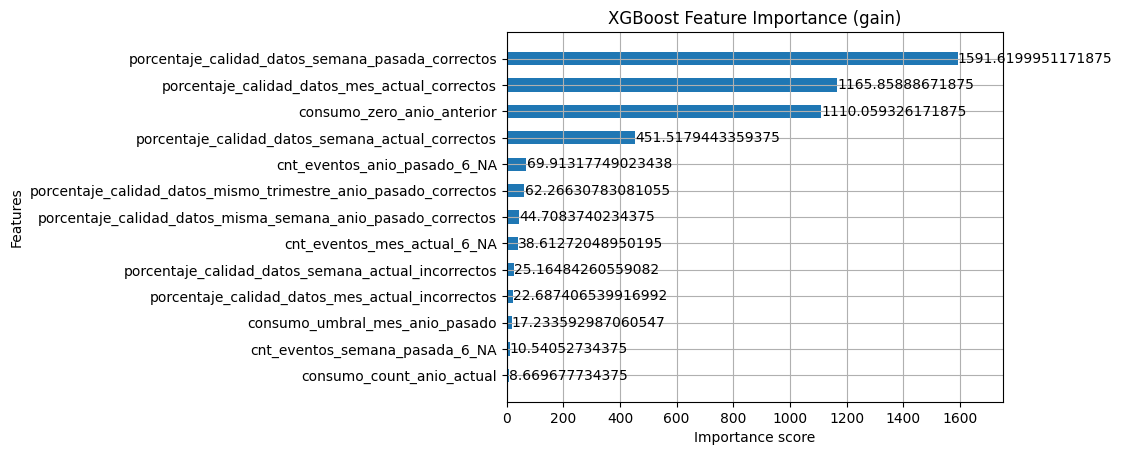

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import plot_importance

# =====================
# Feature Importance con el modelo entrenado
# =====================
# Importancia como "gain" (lo más interpretado: cuánto aporta cada feature en promedio)
importance_dict = model.get_booster().get_score(importance_type='gain')

# Convertir a DataFrame ordenado
importance_df = pd.DataFrame({
    'feature': list(importance_dict.keys()),
    'importance': list(importance_dict.values())
}).sort_values(by='importance', ascending=False)

print(importance_df.head(20))  # Top 20 features

# =====================
# Plot con xgboost (rápido)
# =====================
plt.figure(figsize=(10, 8))
plot_importance(model, importance_type='gain', max_num_features=20, height=0.5, grid=True)
plt.title("XGBoost Feature Importance (gain)")
plt.show()

In [ ]:
final_df["target"] = final_df["target"].astype(int)

# (
#     final_df[["cups_sgc", "cnt_id", "fraude_score_no_supervisado_norm", "xgb_pred_proba", "final_scoring", "target"]]
#     .to_csv("final_results.csv", index=False)
# )

### Correlation between target and other variables

In [45]:
# Seleccionar solo las columnas numéricas para el cálculo de correlación
columnas_numericas = final_df.select_dtypes(include=[np.number]).columns.tolist()
# Eliminar elementos específicos de la lista
columnas_numericas = [col for col in columnas_numericas if col not in ['final_scoring', 'xgb_pred_proba']]

# Asegurar que 'target' esté en las columnas numéricas
if 'target' not in columnas_numericas:
    print("Target no es numérico, convirtiendo...")
    final_df['target'] = pd.to_numeric(final_df['target'], errors='coerce')
    columnas_numericas = final_df.select_dtypes(include=[np.number]).columns.tolist()

# Crear un DataFrame solo con las columnas numéricas
df_numerico = final_df[columnas_numericas].copy()

# Eliminar filas con valores NaN en target
df_numerico = df_numerico.dropna(subset=['target'])

print(f"Trabajando con {len(columnas_numericas)} columnas numéricas")
print(f"Registros válidos para correlación: {len(df_numerico)}")

Trabajando con 1006 columnas numéricas
Registros válidos para correlación: 12118


In [46]:
# 1. CORRELACIÓN DE PEARSON
correlacion_pearson = df_numerico.corr()['target'].drop('target').sort_values(key=abs, ascending=False)

# Crear DataFrame con correlaciones de Pearson
df_correlacion_pearson = pd.DataFrame({
    'variable': correlacion_pearson.index,
    'correlacion_pearson': correlacion_pearson.values,
    'correlacion_pearson_abs': abs(correlacion_pearson.values)
}).reset_index(drop=True)

print("TOP 20 CORRELACIONES PEARSON (en valor absoluto):")
print(df_correlacion_pearson.head(20))

TOP 20 CORRELACIONES PEARSON (en valor absoluto):
                                            variable  correlacion_pearson  \
0                         consumo_zero_anio_anterior             0.498875   
1                         consumo_zero_semana_pasada             0.497870   
2                           consumo_zero_anio_actual             0.497664   
3                      consumo_zero_trimestre_actual             0.497664   
4                            consumo_zero_mes_actual             0.497321   
5                         consumo_zero_semana_actual             0.492492   
6                            consumo_zero_mes_pasado             0.490687   
7                      consumo_zero_trimestre_pasado             0.487801   
8                 consumo_zero_trimestre_anio_pasado             0.476644   
9                       consumo_zero_mes_anio_pasado             0.472728   
10                   consumo_zero_semana_anio_pasado             0.468131   
11  porcentaje_calidad_dat

In [47]:
# 2. CORRELACIÓN DE SPEARMAN
from scipy.stats import spearmanr

correlaciones_spearman = []
variables = [col for col in columnas_numericas if col != 'target']

for variable in variables:
    # Eliminar NaN para esta correlación específica
    datos_limpios = df_numerico[[variable, 'target']].dropna()
    if len(datos_limpios) > 1:
        corr, p_value = spearmanr(datos_limpios[variable], datos_limpios['target'])
        correlaciones_spearman.append({
            'variable': variable,
            'correlacion_spearman': corr,
            'p_value': p_value
        })
    else:
        correlaciones_spearman.append({
            'variable': variable,
            'correlacion_spearman': np.nan,
            'p_value': np.nan
        })

# Crear DataFrame con correlaciones de Spearman
df_correlacion_spearman = pd.DataFrame(correlaciones_spearman)
df_correlacion_spearman['correlacion_spearman_abs'] = abs(df_correlacion_spearman['correlacion_spearman'])
df_correlacion_spearman = df_correlacion_spearman.sort_values('correlacion_spearman_abs', ascending=False)

print("TOP 20 CORRELACIONES SPEARMAN (en valor absoluto):")
print(df_correlacion_spearman.head(20))

C:\Users\GAZARAGOZAG-local\AppData\Local\Temp\ipykernel_17228\379621934.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(datos_limpios[variable], datos_limpios['target'])
C:\Users\GAZARAGOZAG-local\AppData\Local\Temp\ipykernel_17228\379621934.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(datos_limpios[variable], datos_limpios['target'])
C:\Users\GAZARAGOZAG-local\AppData\Local\Temp\ipykernel_17228\379621934.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(datos_limpios[variable], datos_limpios['target'])
C:\Users\GAZARAGOZAG-local\AppData\Local\Temp\ipykernel_17228\379621934.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, p_value = spearmanr(datos_limpios[variable], datos_limpios['target

TOP 20 CORRELACIONES SPEARMAN (en valor absoluto):
                                              variable  correlacion_spearman  \
973                         consumo_zero_anio_anterior              0.704304   
965                           consumo_zero_anio_actual              0.614312   
942                      consumo_zero_trimestre_actual              0.614312   
949                      consumo_zero_trimestre_pasado              0.598312   
957                 consumo_zero_trimestre_anio_pasado              0.588120   
919                            consumo_zero_mes_actual              0.562682   
926                            consumo_zero_mes_pasado              0.552397   
934                       consumo_zero_mes_anio_pasado              0.538679   
903                         consumo_zero_semana_pasada              0.530182   
896                         consumo_zero_semana_actual              0.511428   
911                    consumo_zero_semana_anio_pasado              0

In [48]:
# 3. UNIR TODAS LAS CORRELACIONES EN UN SOLO DATAFRAME
df_correlaciones_completo = df_correlacion_pearson.merge(
    df_correlacion_spearman[['variable', 'correlacion_spearman', 'correlacion_spearman_abs', 'p_value']], 
    on='variable'
)

# Agregar una columna con el promedio de correlaciones absolutas
df_correlaciones_completo['promedio_correlacion_abs'] = (
    df_correlaciones_completo['correlacion_pearson_abs'] + 
    df_correlaciones_completo['correlacion_spearman_abs']
) / 2

# Ordenar por promedio de correlaciones absolutas
df_correlaciones_completo = df_correlaciones_completo.sort_values('promedio_correlacion_abs', ascending=False)

print("DATAFRAME COMPLETO DE CORRELACIONES:")
print(df_correlaciones_completo.head(20))

DATAFRAME COMPLETO DE CORRELACIONES:
                                             variable  correlacion_pearson  \
0                          consumo_zero_anio_anterior             0.498875   
3                       consumo_zero_trimestre_actual             0.497664   
2                            consumo_zero_anio_actual             0.497664   
7                       consumo_zero_trimestre_pasado             0.487801   
8                  consumo_zero_trimestre_anio_pasado             0.476644   
4                             consumo_zero_mes_actual             0.497321   
6                             consumo_zero_mes_pasado             0.490687   
1                          consumo_zero_semana_pasada             0.497870   
9                        consumo_zero_mes_anio_pasado             0.472728   
5                          consumo_zero_semana_actual             0.492492   
10                    consumo_zero_semana_anio_pasado             0.468131   
11   porcentaje_calidad_dat

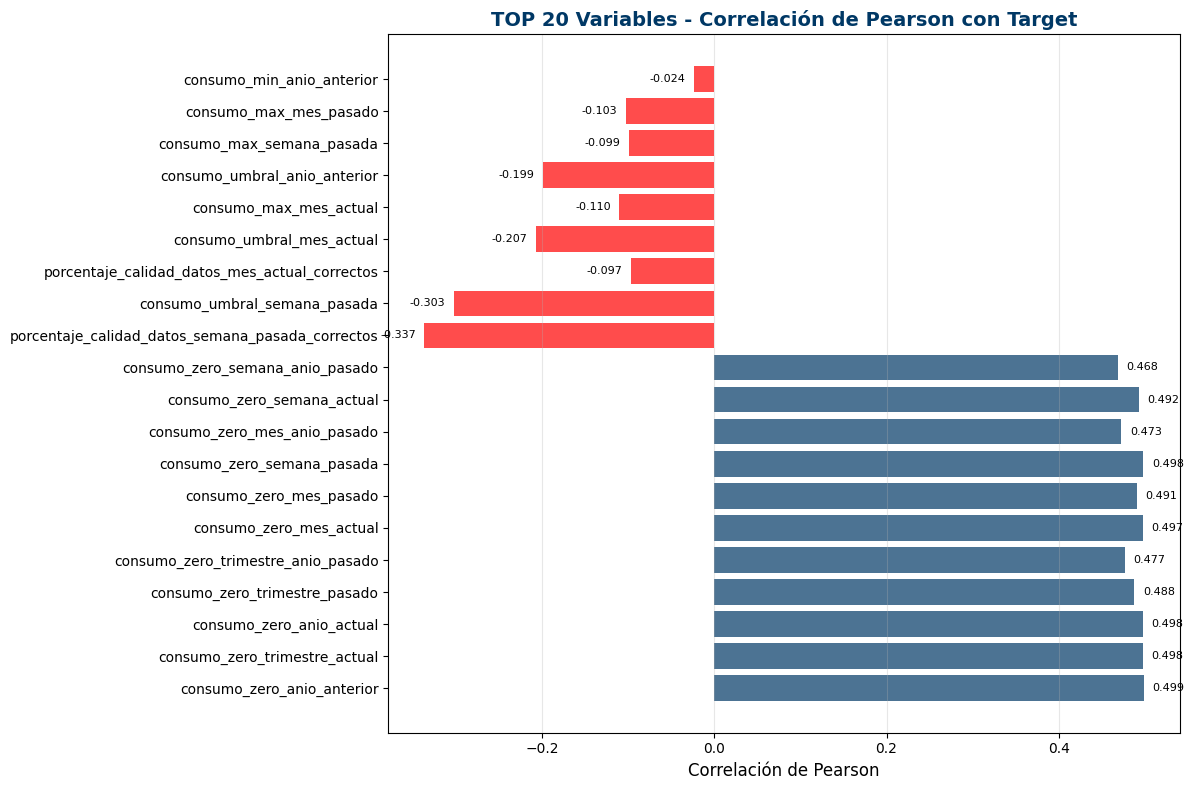

In [49]:
# 4. VISUALIZACIONES

# Colores del proyecto
ufd_orange = "#f26122"
ufd_blue = "#003865"
ufd_gray = "#cccccc"

# GRÁFICO 1: TOP 20 CORRELACIONES PEARSON
plt.figure(figsize=(12, 8))
top_20_pearson = df_correlaciones_completo.head(20)

# Crear colores según el signo de la correlación
colores_pearson = ['red' if x < 0 else ufd_blue for x in top_20_pearson['correlacion_pearson']]

bars = plt.barh(range(len(top_20_pearson)), top_20_pearson['correlacion_pearson'], 
                color=colores_pearson, alpha=0.7)

plt.yticks(range(len(top_20_pearson)), top_20_pearson['variable'], fontsize=10)
plt.xlabel('Correlación de Pearson', fontsize=12)
plt.title('TOP 20 Variables - Correlación de Pearson con Target', fontsize=14, weight="bold", color=ufd_blue)
plt.grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + (0.01 if width >= 0 else -0.01), bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left' if width >= 0 else 'right', va='center', fontsize=8)

plt.tight_layout()
plt.show()

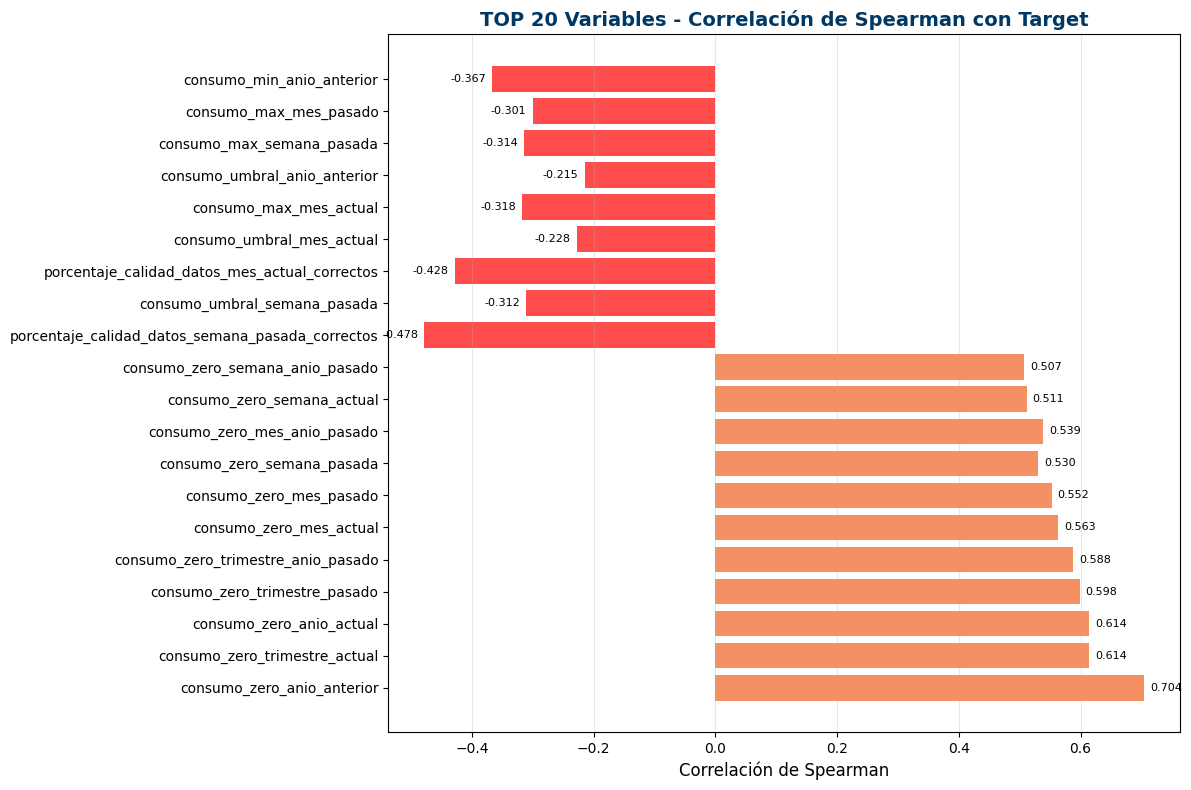

In [50]:
# GRÁFICO 2: TOP 20 CORRELACIONES SPEARMAN
plt.figure(figsize=(12, 8))
top_20_spearman = df_correlaciones_completo.head(20)

# Crear colores según el signo de la correlación
colores_spearman = ['red' if x < 0 else ufd_orange for x in top_20_spearman['correlacion_spearman']]

bars = plt.barh(range(len(top_20_spearman)), top_20_spearman['correlacion_spearman'], 
                color=colores_spearman, alpha=0.7)

plt.yticks(range(len(top_20_spearman)), top_20_spearman['variable'], fontsize=10)
plt.xlabel('Correlación de Spearman', fontsize=12)
plt.title('TOP 20 Variables - Correlación de Spearman con Target', fontsize=14, weight="bold", color=ufd_blue)
plt.grid(axis='x', alpha=0.3)

# Agregar valores en las barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + (0.01 if width >= 0 else -0.01), bar.get_y() + bar.get_height()/2, 
             f'{width:.3f}', ha='left' if width >= 0 else 'right', va='center', fontsize=8)

plt.tight_layout()
plt.show()

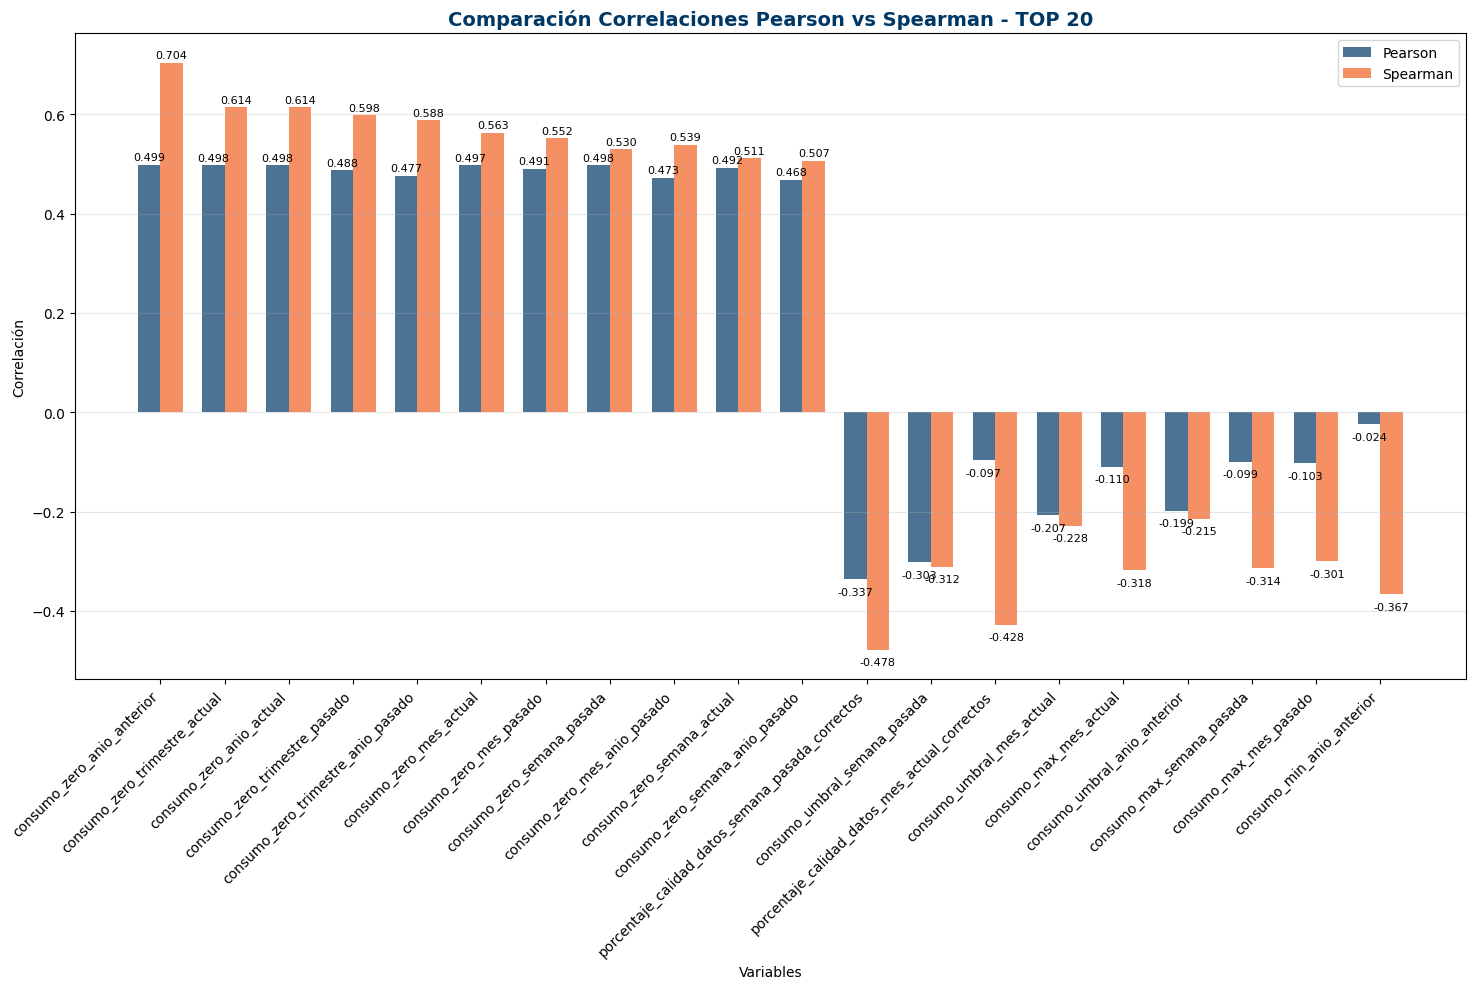

In [51]:
# GRÁFICO 3: COMPARACIÓN LADO A LADO DE PEARSON VS SPEARMAN
plt.figure(figsize=(15, 10))
top_20_comparacion = df_correlaciones_completo.head(20)

x = np.arange(len(top_20_comparacion))
width = 0.35

bars1 = plt.bar(x - width/2, top_20_comparacion['correlacion_pearson'], width, 
                label='Pearson', color=ufd_blue, alpha=0.7)
bars2 = plt.bar(x + width/2, top_20_comparacion['correlacion_spearman'], width, 
                label='Spearman', color=ufd_orange, alpha=0.7)

plt.xlabel('Variables')
plt.ylabel('Correlación')
plt.title('Comparación Correlaciones Pearson vs Spearman - TOP 20', fontsize=14, weight="bold", color=ufd_blue)
plt.xticks(x, top_20_comparacion['variable'], rotation=45, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
def agregar_valores_barras(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (0.005 if height >= 0 else -0.015),
                f'{height:.3f}', ha='center', va='bottom' if height >= 0 else 'top', fontsize=8)

agregar_valores_barras(bars1)
agregar_valores_barras(bars2)

plt.tight_layout()
plt.show()